In [ ]:
pip install pandas matplotlib seaborn jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 57.0 MB/s eta 0:00:00
  Attempting uninstall: jupyter-server
    Found existing installation: jupyter_server 2.18.2
    Uninstalling jupyter_server-2.18.2:
      Successfully uninstalled jupyter_server-2.18.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires jupyter-server==2.18.2, but you have jupyter-server 2.20.0 which is incompatible.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Diwali Sales Data.csv", encoding="unicode_escape")

df.drop(["Status", "unnamed1"], axis=1, inplace=True)
df.dropna(subset=["Amount"], inplace=True)

df["Marital_Status_Label"] = df["Marital_Status"].map({
    0: "Unmarried",
    1: "Married"
})

print(df.head())
print(df.info())
print(df.isnull().sum())

gender_sales = df.groupby("Gender")["Amount"].sum().sort_values(ascending=False)
print(gender_sales)


   User_ID  Cust_name Product_ID Gender Age Group  Age  Marital_Status  \
0  1002903  Sanskriti  P00125942      F     26-35   28               0   
1  1000732     Kartik  P00110942      F     26-35   35               1   
2  1001990      Bindu  P00118542      F     26-35   35               1   
3  1001425     Sudevi  P00237842      M      0-17   16               0   
4  1000588       Joni  P00057942      M     26-35   28               1   

            State      Zone       Occupation Product_Category  Orders  \
0     Maharashtra   Western       Healthcare             Auto       1   
1  Andhra Pradesh  Southern             Govt             Auto       3   
2   Uttar Pradesh   Central       Automobile             Auto       3   
3       Karnataka  Southern     Construction             Auto       2   
4         Gujarat   Western  Food Processing             Auto       2   

    Amount Marital_Status_Label  
0  23952.0            Unmarried  
1  23934.0              Married  
2  23924.0    

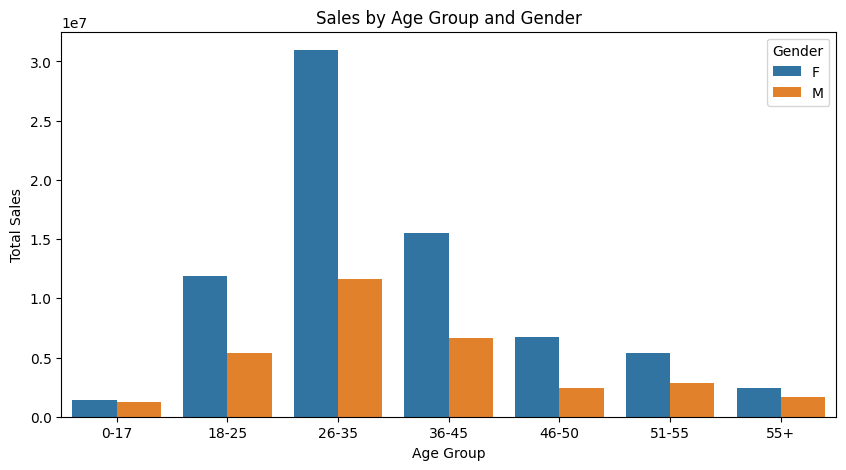

In [ ]:
age_gender_sales = df.groupby(["Age Group", "Gender"])["Amount"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=age_gender_sales, x="Age Group", y="Amount", hue="Gender")
plt.title("Sales by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.show()

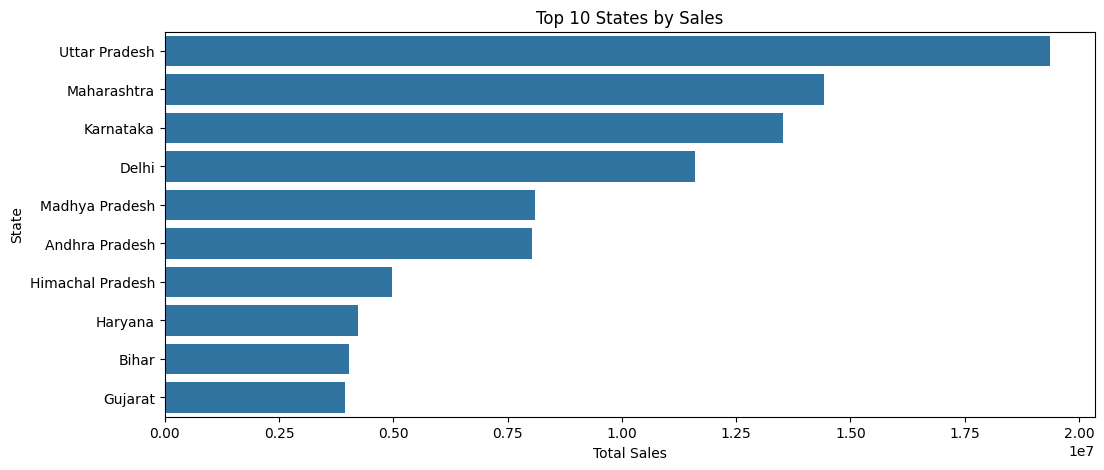

In [ ]:
state_sales = df.groupby("State")["Amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=state_sales.values, y=state_sales.index)
plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.show()

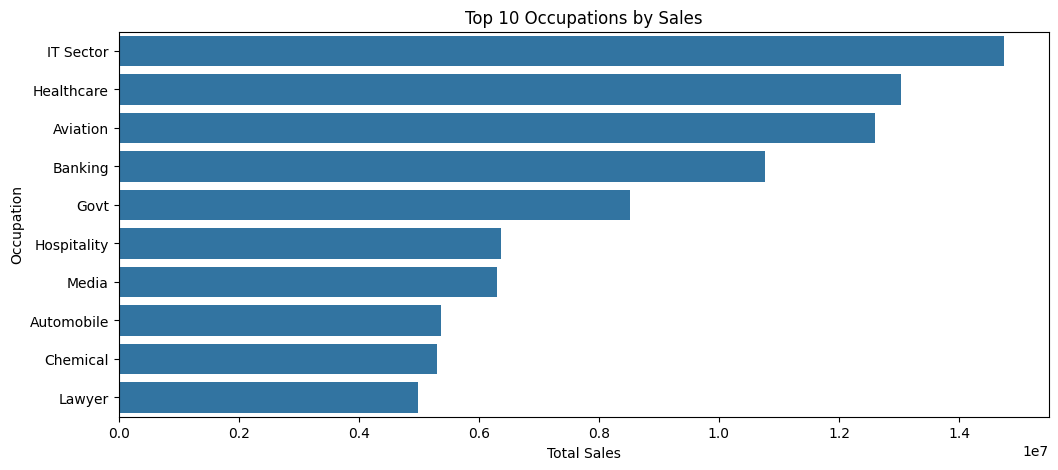

In [ ]:
occupation_sales = df.groupby("Occupation")["Amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=occupation_sales.values, y=occupation_sales.index)
plt.title("Top 10 Occupations by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Occupation")
plt.show()

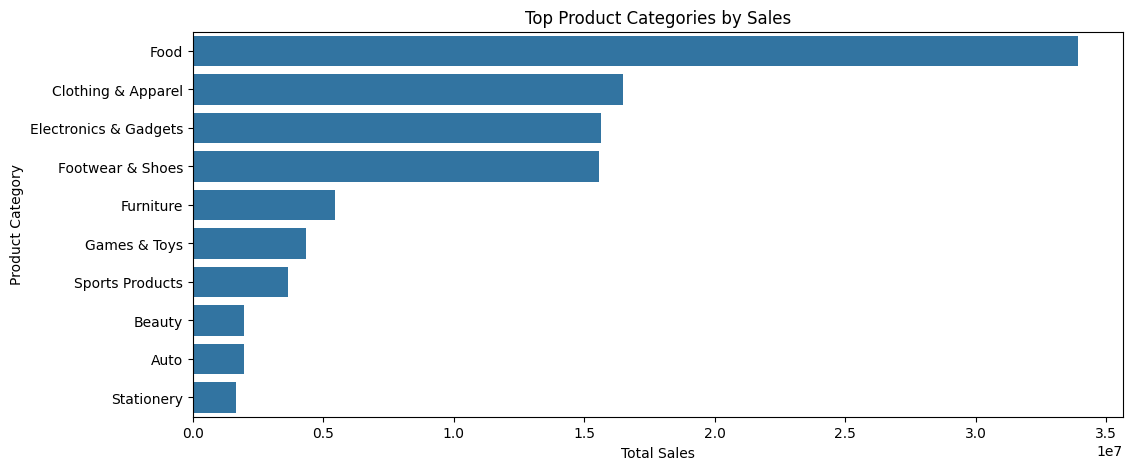

In [ ]:
category_sales = df.groupby("Product_Category")["Amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=category_sales.values, y=category_sales.index)
plt.title("Top Product Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")
plt.show()